In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import ArrayLike, NDArray

w = np.array([1, 1])
d = 0

 ## Note
 **法線ベクトル$w$の原点を通る平面の式:**
 $$ w \cdot x = 0$$

In [ ]:
def g(x0: NDArray | ArrayLike) -> NDArray:
    # x0を受け取りx1を返す閉形式の直線の関数
    x0 = np.asarray(x0)
    return -(w[0] * x0 + d) / w[1]


print(f"{g([-1, 0, 1]) = }")

g([-1, 0, 1]) = array([ 1.,  0., -1.])


 ## Note
 **原点を通る直線と点の距離:**
 直線上にない任意の点$p$と直線の距離は
 法線方向の写像の絶対値であり、
 内積を法線ベクトル方向の単位ベクトルで表現すると
 $$ w \cdot p = |w|(e \cdot p)$$
 $$ e \cdot p = (w \cdot p) / |w| $$
 $$ 距離 = |w \cdot p| / |w| $$
 で計算される

In [ ]:
p = np.array([3, 0])
dist = np.abs(w @ p) / np.linalg.norm(w)

e = w / np.linalg.norm(w)
l = e * dist

<ipython-input-4-b868b7cbb16f>:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


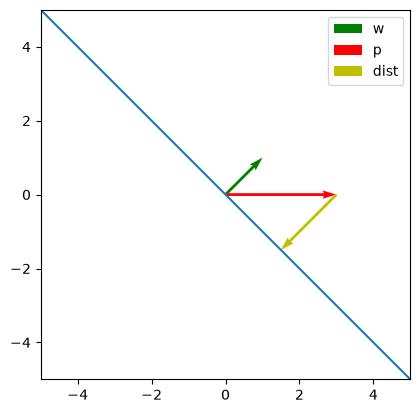

In [ ]:
params = {
    "angles": "xy",
    "scale_units": "xy",
    "scale": 1,
}


x = np.linspace(-5, 5, 2)
fig, ax = plt.subplots()
fig.gca().set_aspect("equal")
ax.plot(x, g(x))
ax.quiver(0, 0, *w, label="w", color=["g"], **params)
ax.quiver(0, 0, *p, label="p", color=["r"], **params)
ax.quiver(p[0], p[1], *-l, label="dist", color=["y"], **params)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.legend()
fig.show()

 **平面の式の解釈:** 距離の式より平面の式左辺$w \cdot x$は符号付きの距離に比例する量であり、
 直線からの離れ具合と考えることができる

In [ ]:
def f(X: NDArray | ArrayLike) -> NDArray:
    return X @ w + d


print(f"""
{w = }, {d = }
{f([1, 1]) = }
{f([-1, 1]) = }
""")


w = array([1, 1]), d = 0
f([1, 1]) = np.int64(2)
f([-1, 1]) = np.int64(0)



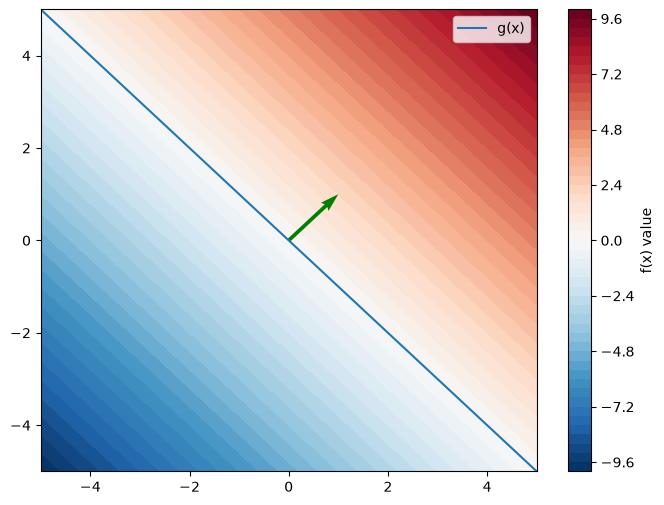

In [ ]:
x1_range = np.linspace(-5, 5, 200)
x2_range = np.linspace(-5, 5, 200)
X1, X2 = np.meshgrid(x1_range, x2_range)
X = np.stack([X1, X2], axis=-1)
Z = f(X)

plt.figure(figsize=(8, 6))
heatmap = plt.contourf(X1, X2, Z, levels=50, cmap="RdBu_r")
cbar = plt.colorbar(heatmap)
cbar.set_label("f(x) value")

x = np.linspace(-5, 5)
plt.plot(x, g(x), label="g(x)")

params = {
    "angles": "xy",
    "scale_units": "xy",
    "scale": 1,
}

plt.quiver(0, 0, *w, color=["g"], **params)

plt.legend()